# Loan data pipeline

In [19]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


NONE_LABEL = "None"
EPOCH = pd.Timestamp("1970-01-01")

DROP_STATUSES = [
    "Current",
    "In Grace Period",
    "Late (16-30 days)",
]

GOOD_STATUSES = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid",
]

BAD_STATUSES = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
    "Late (31-120 days)",
]

HIGH_PAY_KEYWORDS = [
    "doctor", "physician", "surgeon", "dentist", "lawyer", "attorney",
    "engineer", "software", "developer", "architect", "consultant",
    "director", "executive", "ceo", "cfo", "vice president", " vp",
    "manager", "professor", "pharmacist", "analyst", "pilot",
    "nurse practitioner", "financial adviser", "investment",
]

LOW_PAY_KEYWORDS = [
    "cashier", "clerk", "server", "waiter", "waitress", "barista",
    "janitor", "cleaner", "housekeep", "dishwash", "crew member",
    "retail", "sales associate", "stock clerk", "security guard",
    "landscap", "laborer", "warehouse", "picker", "packer",
    "helper", "intern", "student", "delivery driver", "fast food",
    "mcdonald", "burger king", "pizza hut", "subway", "starbucks",
]

MTHS_EVENT_COLS = [
    "mths_since_last_delinq",
    "mths_since_last_record",
    "mths_since_last_major_derog",
]

LEAKAGE_OR_UNNECESSARY = [
    "id",
    "member_id",
    "url",
    "title",
    "loan_status",
    "funded_amnt",
    "funded_amnt_inv",
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "last_credit_pull_d",
]

SPARSE_OR_LOW_VALUE = [
    "tot_coll_amt",
    "total_rev_hi_lim",
    "tot_cur_bal",
]

DATE_COLUMNS = [
    "issue_d",
    "earliest_cr_line",
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d",
]


def parse_emp_length(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text == "< 1 year":
        return 0.5
    if "+" in text:
        return float(text.split("+")[0])
    return float(text.split()[0])


def job_pay_tier(title):
    if pd.isna(title):
        return "none"
    text = str(title).lower()
    if any(keyword in text for keyword in HIGH_PAY_KEYWORDS):
        return "high"
    if any(keyword in text for keyword in LOW_PAY_KEYWORDS):
        return "low"
    return "medium"


def format_months_since(value):
    if pd.isna(value):
        return NONE_LABEL
    num = float(value)
    return str(int(num)) if num.is_integer() else str(num)


class CustomTransformer(BaseEstimator, TransformerMixin):
    """Replicates preprocessing in data_learning.ipynb (sections 2–10)."""

    def __init__(self, return_label=False):
        self.return_label = return_label

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = self._preprocess(X)
        if self.return_label:
            return df.drop(columns=["label"]), df["label"]
        return df

    def _preprocess(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        df = self._drop_useless_columns(df)
        df = self._standardize_missing_values(df)
        df = self._fix_dtypes(df)
        df = self._filter_and_label(df)
        df = self._engineer_features(df)
        df = self._encode_event_columns(df)
        df = self._drop_leaky_and_sparse(df)
        df = self._pre_model_cleanup(df)
        df = self._fill_emp_length_and_annual_inc(df)
        return df

    @staticmethod
    def _drop_useless_columns(df):
        if "Unnamed: 0" in df.columns:
            df = df.drop(columns=["Unnamed: 0"])
        empty_columns = df.columns[df.isna().all()].tolist()
        return df.drop(columns=empty_columns)

    @staticmethod
    def _standardize_missing_values(df):
        text_columns = df.select_dtypes(include=["object", "string"]).columns
        for col in text_columns:
            df[col] = df[col].replace(r"^\s*$", np.nan, regex=True)
        return df

    @staticmethod
    def _fix_dtypes(df):
        df["term"] = df["term"].astype(str).str.extract(r"(\d+)").astype(float)
        for col in DATE_COLUMNS:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], format="%b-%y", errors="coerce")
        for col in ["id", "member_id"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
        return df

    @staticmethod
    def _filter_and_label(df):
        df = df[~df["loan_status"].isin(DROP_STATUSES)].copy()
        status_to_label = {s: 1 for s in GOOD_STATUSES} | {s: 0 for s in BAD_STATUSES}
        df["label"] = df["loan_status"].map(status_to_label)
        return df

    @staticmethod
    def _engineer_features(df):
        df["has_desc"] = df["desc"].notna().astype(int)
        df = df.drop(columns=["desc"])
        df["emp_length"] = df["emp_length"].map(parse_emp_length)
        df["home_ownership"] = (
            df["home_ownership"].replace({"ANY": "OTHER"}).str.upper()
        )
        df["emp_pay_tier"] = df["emp_title"].apply(job_pay_tier)
        return df.drop(columns=["emp_title"])

    @staticmethod
    def _encode_event_columns(df):
        for col in MTHS_EVENT_COLS:
            df[col] = df[col].apply(format_months_since)
        df["next_pymnt_d"] = df["next_pymnt_d"].apply(
            lambda x: pd.Timestamp(x).strftime("%Y-%m-%d") if pd.notna(x) else NONE_LABEL
        )
        return df

    @staticmethod
    def _drop_leaky_and_sparse(df):
        drop_columns = LEAKAGE_OR_UNNECESSARY + SPARSE_OR_LOW_VALUE
        cols_to_drop = [c for c in drop_columns if c in df.columns]
        return df.drop(columns=cols_to_drop)

    @staticmethod
    def _pre_model_cleanup(df):
        df = df.drop(columns=["pymnt_plan", "application_type"], errors="ignore")
        for col in ["issue_d", "earliest_cr_line"]:
            if col in df.columns:
                df[col] = ((df[col] - EPOCH).dt.days).astype("Int64")
        for col in MTHS_EVENT_COLS:
            df[col] = df[col].apply(
                lambda x: -1 if x == NONE_LABEL else int(float(x))
            ).astype("int64")
        df["initial_list_status"] = (
            df["initial_list_status"].str.lower() == "w"
        ).astype("int64")
        df["next_pymnt_d"] = df["next_pymnt_d"].apply(
            lambda x: -1
            if x == NONE_LABEL
            else int((pd.Timestamp(x) - EPOCH).days)
        ).astype("int64")
        return df.drop(columns=["zip_code"], errors="ignore")

    @staticmethod
    def _fill_emp_length_and_annual_inc(df):
        df["emp_length"] = df["emp_length"].fillna(0)
        df["annual_inc"] = df["annual_inc"].fillna(0)
        return df

In [20]:
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
DATA_PATH = "loan_data_2007_2014.csv"

raw_df = pd.read_csv(DATA_PATH, low_memory=False)

prep = CustomTransformer()
cleaned = prep.fit_transform(raw_df)   # (237695, 33) on the full CSV


In [21]:
cleaned.info()

<class 'pandas.DataFrame'>
Index: 237695 entries, 0 to 466283
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    237695 non-null  int64  
 1   term                         237695 non-null  float64
 2   int_rate                     237695 non-null  float64
 3   installment                  237695 non-null  float64
 4   grade                        237695 non-null  str    
 5   sub_grade                    237695 non-null  str    
 6   emp_length                   237695 non-null  float64
 7   home_ownership               237695 non-null  str    
 8   annual_inc                   237695 non-null  float64
 9   verification_status          237695 non-null  str    
 10  issue_d                      237695 non-null  Int64  
 11  purpose                      237695 non-null  str    
 12  addr_state                   237695 non-null  str    
 13  dti            

In [22]:
missing_counts = cleaned.isnull().sum()
print(missing_counts)

loan_amnt                        0
term                             0
int_rate                         0
installment                      0
grade                            0
sub_grade                        0
emp_length                       0
home_ownership                   0
annual_inc                       0
verification_status              0
issue_d                          0
purpose                          0
addr_state                       0
dti                              0
delinq_2yrs                     29
earliest_cr_line                29
inq_last_6mths                  29
mths_since_last_delinq           0
mths_since_last_record           0
open_acc                        29
pub_rec                         29
revol_bal                        0
revol_util                     231
total_acc                       29
initial_list_status              0
next_pymnt_d                     0
collections_12_mths_ex_med     145
mths_since_last_major_derog      0
policy_code         

## Splitting Train and Testing data

In [23]:
from sklearn.model_selection import train_test_split

X = cleaned.drop(columns=['label']) 
y = cleaned['label']                

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,          
    random_state=42,         
    stratify=y             
)

print("Training class distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting class distribution:\n", y_test.value_counts(normalize=True))

Training class distribution:
 label
1    0.785576
0    0.214424
Name: proportion, dtype: float64

Testing class distribution:
 label
1    0.785566
0    0.214434
Name: proportion, dtype: float64


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder

CAT_FEATURES = [
    "grade",
    "sub_grade",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "emp_pay_tier",
]
NUM_FEATURES = [c for c in X_train.columns if c not in CAT_FEATURES]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", TargetEncoder(target_type="binary")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUM_FEATURES),
        ("cat", categorical_pipeline, CAT_FEATURES),
    ]
)

# Fit on train only; pass y so TargetEncoder can learn category means
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Train matrix: {X_train_processed.shape}")
print(f"Test matrix:  {X_test_processed.shape}")

# Full modeling pipeline (add your estimator after preprocess)
model_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        # ("classifier", YourEstimator(...)),
    ]
)

Train matrix: (190156, 32)
Test matrix:  (47539, 32)


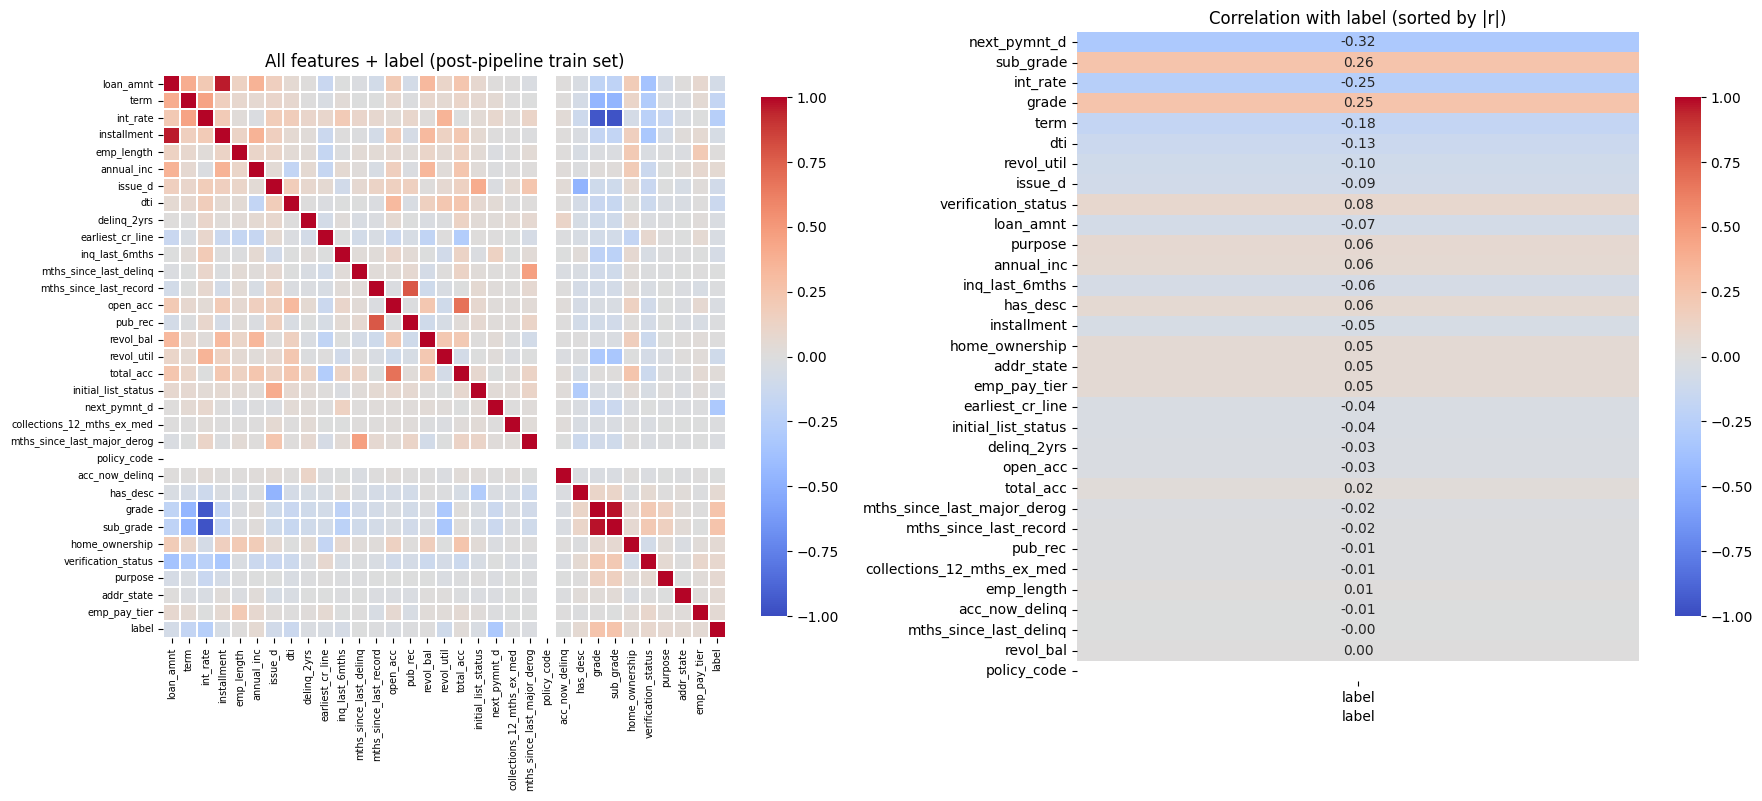

Correlation with label:
 next_pymnt_d                  -0.318901
sub_grade                      0.256355
int_rate                      -0.254426
grade                          0.250317
term                          -0.175858
dti                           -0.126438
revol_util                    -0.096609
issue_d                       -0.091261
verification_status            0.083919
loan_amnt                     -0.072801
purpose                        0.062771
annual_inc                     0.062164
inq_last_6mths                -0.056326
has_desc                       0.056322
installment                   -0.053228
home_ownership                 0.049577
addr_state                     0.049268
emp_pay_tier                   0.048300
earliest_cr_line              -0.036651
initial_list_status           -0.035216
delinq_2yrs                   -0.028033
open_acc                      -0.025621
total_acc                      0.023664
mths_since_last_major_derog   -0.023147
mths_since_last

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# After preprocess pipeline: impute → target-encode (cats) → scale (nums)
PROCESSED_FEATURE_NAMES = NUM_FEATURES + CAT_FEATURES

processed_df = pd.DataFrame(
    X_train_processed,
    columns=PROCESSED_FEATURE_NAMES,
    index=y_train.index,
)
processed_df["label"] = y_train.values

corr = processed_df.corr()
label_corr = corr["label"].drop("label").sort_values(key=lambda s: s.abs(), ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
    ax=axes[0],
)
axes[0].set_title("All features + label (post-pipeline train set)")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].tick_params(axis="y", labelsize=7)

sns.heatmap(
    label_corr.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
    ax=axes[1],
)
axes[1].set_title("Correlation with label (sorted by |r|)")
axes[1].set_xlabel("label")

plt.tight_layout()
plt.show()

print("Correlation with label:\n", label_corr)

## Grid search

Best estimators and the fitted preprocessor are saved under `saved_models/` with joblib.

In [ ]:
import time
from pathlib import Path

import joblib
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

try:
    from xgboost import XGBClassifier

    HAS_XGB = True
except ImportError:
    HAS_XGB = False

BAD_CLASS = 0  # bad / default
XGB_SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
SCORING = make_scorer(f1_score, pos_label=BAD_CLASS)
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

GRID_SEARCH_CONFIGS = {
    "LogisticRegression": {
        "estimator": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        ),
        "param_grid": {
            "C": [0.01, 0.1, 1.0, 10.0],
            "solver": ["lbfgs", "saga"],
        },
    },
    "SVM_linear": {
        "estimator": LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=5000,
        ),
        "param_grid": {
            "C": [0.01, 0.1, 1.0, 10.0],
        },
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_leaf": [1, 5],
        },
    },
    "HistGradientBoosting": {
        "estimator": HistGradientBoostingClassifier(
            class_weight="balanced",
            random_state=42,
        ),
        "param_grid": {
            "max_depth": [5, 10],
            "learning_rate": [0.05, 0.1],
            "max_iter": [100, 200],
        },
    },
}

if HAS_XGB:
    GRID_SEARCH_CONFIGS["XGBoost"] = {
        "estimator": XGBClassifier(
            scale_pos_weight=XGB_SCALE_POS_WEIGHT,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [4, 6, 8],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
        },
    }
else:
    print("XGBoost not installed — skip with: pip install xgboost")


def _positive_class_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)


def grid_search_with_progress(
    model_name,
    estimator,
    param_grid,
    X,
    y,
    *,
    cv=CV,
    scoring=SCORING,
    n_jobs=-1,
    refit=True,
    verbose=2,
    model_index=None,
    model_total=None,
):
    """Run GridSearchCV and print which model / how many fits are scheduled."""
    n_combos = len(list(ParameterGrid(param_grid)))
    n_fits = n_combos * cv.get_n_splits(X, y)

    header = (
        f"Model {model_index}/{model_total}: {model_name}"
        if model_index
        else f"Model: {model_name}"
    )
    print("" + "=" * 60)
    print(header)
    print("=" * 60)
    print(f"  Parameter combinations: {n_combos}")
    print(f"  CV folds: {cv.get_n_splits(X, y)}  ->  total fits: {n_fits}")
    print("  Training now...")

    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        refit=refit,
        verbose=verbose,
        return_train_score=False,
    )
    t0 = time.perf_counter()
    search.fit(X, y)
    elapsed = time.perf_counter() - t0

    print(f"Finished {model_name} in {elapsed:.1f}s")
    print(f"  Best CV F1 (bad class): {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search


def run_all_grid_searches(configs, X, y, **grid_kwargs):
    """Grid-search every model in `configs`; returns dict of GridSearchCV results."""
    results = {}
    names = list(configs.keys())
    total = len(names)

    for i, name in enumerate(names, start=1):
        cfg = configs[name]
        results[name] = grid_search_with_progress(
            name,
            cfg["estimator"],
            cfg["param_grid"],
            X,
            y,
            model_index=i,
            model_total=total,
            **grid_kwargs,
        )

    print("" + "=" * 60)
    print("All grid searches complete.")
    print("=" * 60)
    return results


grid_searches = run_all_grid_searches(
    GRID_SEARCH_CONFIGS,
    X_train_processed,
    y_train,
)

grid_summary_rows = []
for name, gs in grid_searches.items():
    best = gs.best_estimator_
    y_pred = best.predict(X_test_processed)
    y_score = _positive_class_scores(best, X_test_processed)
    grid_summary_rows.append(
        {
            "model": name,
            "best_cv_f1_bad": gs.best_score_,
            "best_params": gs.best_params_,
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision_bad": precision_score(
                y_test, y_pred, pos_label=BAD_CLASS, zero_division=0
            ),
            "test_recall_bad": recall_score(
                y_test, y_pred, pos_label=BAD_CLASS, zero_division=0
            ),
            "test_f1_bad": f1_score(y_test, y_pred, pos_label=BAD_CLASS, zero_division=0),
            "test_roc_auc": roc_auc_score(y_test, y_score),
        }
    )

grid_summary_df = pd.DataFrame(grid_summary_rows).sort_values(
    "test_f1_bad", ascending=False
).reset_index(drop=True)
grid_summary_df

In [30]:
SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(preprocessor, SAVE_DIR / "preprocessor.joblib")

for name, gs in grid_searches.items():
    safe_name = name.replace(" ", "_")
    joblib.dump(gs.best_estimator_, SAVE_DIR / f"{safe_name}_best_estimator.joblib")
    joblib.dump(gs, SAVE_DIR / f"{safe_name}_gridsearch.joblib")

    inference_pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("classifier", gs.best_estimator_),
        ]
    )
    joblib.dump(inference_pipeline, SAVE_DIR / f"{safe_name}_pipeline.joblib")

grid_summary_df.to_csv(SAVE_DIR / "grid_search_summary.csv", index=False)
joblib.dump(grid_summary_df, SAVE_DIR / "grid_search_summary.joblib")

print(f"Saved to {SAVE_DIR.resolve()}:")
for path in sorted(SAVE_DIR.iterdir()):
    print(f"  {path.name}")

Saved to D:\Programming\Book\Part 2\internship\saved_models:
  grid_search_summary.csv
  grid_search_summary.joblib
  HistGradientBoosting_best_estimator.joblib
  HistGradientBoosting_gridsearch.joblib
  HistGradientBoosting_pipeline.joblib
  LogisticRegression_best_estimator.joblib
  LogisticRegression_gridsearch.joblib
  LogisticRegression_pipeline.joblib
  preprocessor.joblib
  RandomForest_best_estimator.joblib
  RandomForest_gridsearch.joblib
  RandomForest_pipeline.joblib
  SVM_linear_best_estimator.joblib
  SVM_linear_gridsearch.joblib
  SVM_linear_pipeline.joblib
  XGBoost_best_estimator.joblib
  XGBoost_gridsearch.joblib
  XGBoost_pipeline.joblib


In [ ]:
import joblib
from pathlib import Path

import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras

BAD_CLASS = 0
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)

n_features = X_train_processed.shape[1]

X_tr = np.asarray(X_train_processed, dtype=np.float32)
X_te = np.asarray(X_test_processed, dtype=np.float32)
y_tr = np.asarray(y_train, dtype=np.float32)
y_te = np.asarray(y_test, dtype=np.float32)

# Validation slice from train only (for early stopping — not the test set)
rng = np.random.default_rng(RANDOM_SEED)
val_size = int(0.1 * len(X_tr))
val_idx = rng.choice(len(X_tr), size=val_size, replace=False)
train_idx = np.setdiff1d(np.arange(len(X_tr)), val_idx)

X_fit, y_fit = X_tr[train_idx], y_tr[train_idx]
X_val, y_val = X_tr[val_idx], y_tr[val_idx]

classes = np.unique(y_tr)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("class_weight:", class_weight)

mlp = keras.Sequential(
    [
        keras.layers.Input(shape=(n_features,)),
        # Block 1: wide representation of all 32 inputs
        keras.layers.Dense(128, activation="relu", name="hidden_128"),
        keras.layers.Dropout(0.3, name="dropout_0_3"),
        # Block 2: compress interactions
        keras.layers.Dense(64, activation="relu", name="hidden_64"),
        keras.layers.Dropout(0.2, name="dropout_0_2"),
        # Block 3: bottleneck before decision
        keras.layers.Dense(32, activation="relu", name="hidden_32"),
        # Output: P(good loan) = P(label == 1)
        keras.layers.Dense(1, activation="sigmoid", name="output_prob"),
    ],
    name="loan_default_mlp",
)

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

mlp.summary()

history = mlp.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ],
    verbose=1,
)

# Test metrics (same focus as grid search: class 0 = bad)
y_proba = mlp.predict(X_te, verbose=0).ravel()
y_pred = (y_proba >= 0.5).astype(int)

mlp_metrics = {
    "accuracy": accuracy_score(y_te, y_pred),
    "precision_bad": precision_score(y_te, y_pred, pos_label=BAD_CLASS, zero_division=0),
    "recall_bad": recall_score(y_te, y_pred, pos_label=BAD_CLASS, zero_division=0),
    "f1_bad": f1_score(y_te, y_pred, pos_label=BAD_CLASS, zero_division=0),
    "roc_auc": roc_auc_score(y_te, y_proba),
}
print("\nMLP test metrics:")
for k, v in mlp_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_te, y_pred, digits=3))

class_weight: {0: 2.3318291067837347, 1: 0.6364756128583096}


Model: "loan_default_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_128 (Dense)              │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0_3 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_64 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0_2 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_32 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_prob (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.7171 - loss: 0.6072 - precision: 0.8713 - recall: 0.6758 - val_auc: 0.7529 - val_loss: 0.5648 - val_precision: 0.8817 - val_recall: 0.7275
Epoch 2/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7427 - loss: 0.5831 - precision: 0.8792 - recall: 0.7023 - val_auc: 0.7548 - val_loss: 0.5593 - val_precision: 0.8825 - val_recall: 0.7292
Epoch 3/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7469 - loss: 0.5795 - precision: 0.8809 - recall: 0.7030 - val_auc: 0.7551 - val_loss: 0.5575 - val_precision: 0.8833 - val_recall: 0.7166
Epoch 4/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7488 - loss: 0.5776 - precision: 0.8809 - recall: 0.7048 - val_auc: 0.7555 - val_loss: 0.5576 - val_precision: 0.8822 - val_recall: 0.7293
Epoch 5/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7506 - loss: 0.5762 - precision: 0.8819 - recall: 0.7056 - val_auc: 0.7561 - val_loss: 0.5574 - val_precision: 0.8829 - val_recall: 0.7234


In [ ]:
SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(mlp, SAVE_DIR / "loan_default_mlp.joblib")
joblib.dump(mlp_metrics, SAVE_DIR / "mlp_test_metrics.joblib")
print(f"\nSaved: {SAVE_DIR / 'loan_default_mlp.joblib'}")
print(f"Saved: {SAVE_DIR / 'mlp_test_metrics.joblib'}")

# Ringkasan Proyek End-to-End (Bahasa Indonesia)

Dokumen ini menjelaskan alur lengkap di `main.ipynb`: prediksi **kredit macet** (pinjaman Lending Club 2007–2014) dari data mentah hingga model tersimpan.

---

## 1. Tujuan bisnis

Membangun model yang memprediksi apakah pinjaman akan **lunas baik (good)** atau **macet / gagal bayar (bad)** berdasarkan informasi saat **pengajuan pinjaman**, bukan setelah pinjaman berjalan.

| Label | Arti | Contoh `loan_status` |
|-------|------|----------------------|
| **1 (good)** | Pinjaman berakhir positif | Fully Paid |
| **0 (bad)** | Gagal bayar / macet | Charged Off, Default, Late (31–120 days) |

**Mengapa fokus kelas 0?** Data tidak seimbang (~79% good, ~21% bad). Akurasi saja bisa tinggi meski model jarang mendeteksi pinjaman macet. Metrik utama: **F1, precision, recall untuk kelas bad (0)**.

---

## 2. Alur solusi (end-to-end)

```
CSV mentah → CustomTransformer → Train/Test split
    → Preprocessor (impute + target encode + scale)
    → Grid Search (5 model sklearn) → Simpan joblib
    → MLP (TensorFlow) → Simpan joblib
```

### Tahap A — `CustomTransformer` (pembersihan & fitur)

| Langkah | Apa yang dilakukan | Alasan |
|---------|-------------------|--------|
| Hapus kolom kosong 100% | 17 kolom tanpa nilai | Tidak informatif |
| Blank → NaN | String kosong diseragamkan | Hitung missing konsisten |
| Parse tipe data | `term` → angka; tanggal `%b-%y` | Siap untuk model |
| Filter baris | Buang status belum final (Current, In Grace, Late 16–30) | Label belum pasti |
| Buat `label` | Map `loan_status` → 0/1 | Target supervised |
| Feature engineering | `has_desc`, `emp_pay_tier`, `emp_length` numerik, dll. | Kurangi noise teks; tangkap sinyal pekerjaan |
| Encode “tidak ada event” | Bulan/tanggal kosong → `-1` atau `"None"` | Bukan missing acak, artinya “tidak pernah terjadi” |
| Drop leakage | Pembayaran, saldo setelah origination | Model tidak boleh “curang” pakai masa depan |
| Drop sparse | `tot_coll_amt`, dll. | Banyak missing di tahun awal dataset |

**Output:** ~237.695 baris × 33 kolom (32 fitur + `label`).

### Tahap B — Split & preprocessor

| Pilihan | Alasan |
|---------|--------|
| **Stratified 80/20** | Proporsi good/bad sama di train & test |
| **Imputer most_frequent** | Sederhana; cocok untuk sedikit missing numerik |
| **Target encoding** (7 kolom kategorikal) | `grade`, `state`, `purpose`, dll. punya banyak level; one-hot terlalu lebar |
| **StandardScaler** (numerik) | Penting untuk Logistic, SVM, MLP |

**Output:** matriks **32 fitur** siap model.

### Tahap C — Grid search

| Model | Alasan dipilih |
|-------|----------------|
| Logistic Regression | Baseline interpretable, cepat |
| Linear SVM | Batas linear kuat; cocok data besar (bukan RBF yang lambat) |
| Random Forest | Interaksi non-linear tabular |
| HistGradientBoosting | Boosting cepat (sklearn), tanpa XGB wajib |
| XGBoost | Sering terbaik di data tabular kredit |

- **CV:** 3-fold stratified  
- **Scoring:** F1 kelas 0 (bad)  
- **Class weight balanced** / `scale_pos_weight` untuk imbalance  

### Tahap D — MLP

| Pilihan | Alasan |
|---------|--------|
| Arsitektur 128→64→32 | Funnel: banyak fitur → representasi ringkas → probabilitas |
| Dropout | Kurangi overfitting |
| `class_weight` balanced | Sama seperti model sklearn |
| Early stopping (val dari train) | Hindari overfit; test tidak dipakai untuk stop |
| **Tidak pakai PCA** | Hanya 32 fitur; PCA kurang membantu di tabular kecil |

### Tahap E — Penyimpanan (`saved_models/`)

Preprocessor, model terbaik per algoritma, pipeline inferensi (preprocess + classifier), ringkasan grid search, MLP — agar prediksi bisa dijalankan tanpa re-train.

---

## 3. Kesimpulan praktis

1. **Pembersihan ketat** menghindari *data leakage* — kunci di domain kredit.  
2. **Imbalance** ditangani lewat bobot kelas & metrik F1 bad, bukan hanya akurasi.  
3. **Model tabular** (XGBoost / HistGradientBoosting) biasanya kompetitif; MLP sebagai alternatif / ensemble.  
4. **Threshold 0.5** default; bisa dituning jika ingin lebih banyak deteksi pinjaman macet.

Sel di bawah ini membuat **infografis** (matplotlib/seaborn): alur pipeline, ringkasan data, korelasi fitur, perbandingan model (**accuracy, precision, recall, F1** kelas bad), heatmap metrik, dan arsitektur MLP. **Jalankan semua sel di atas terlebih dahulu**, atau infografis akan memuat data dari `saved_models/` jika tersedia.

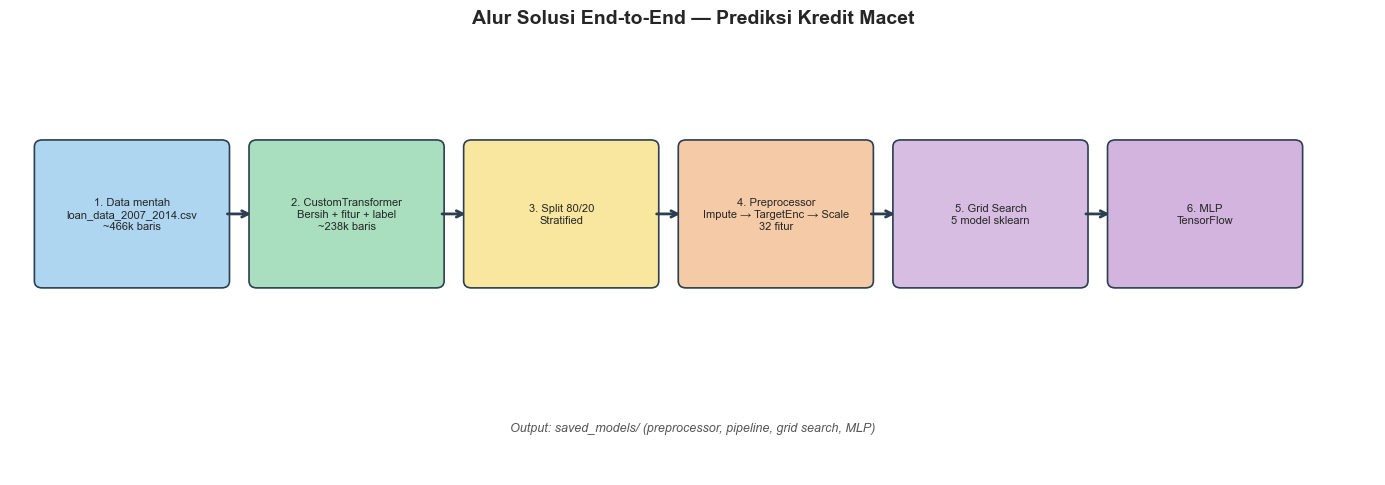

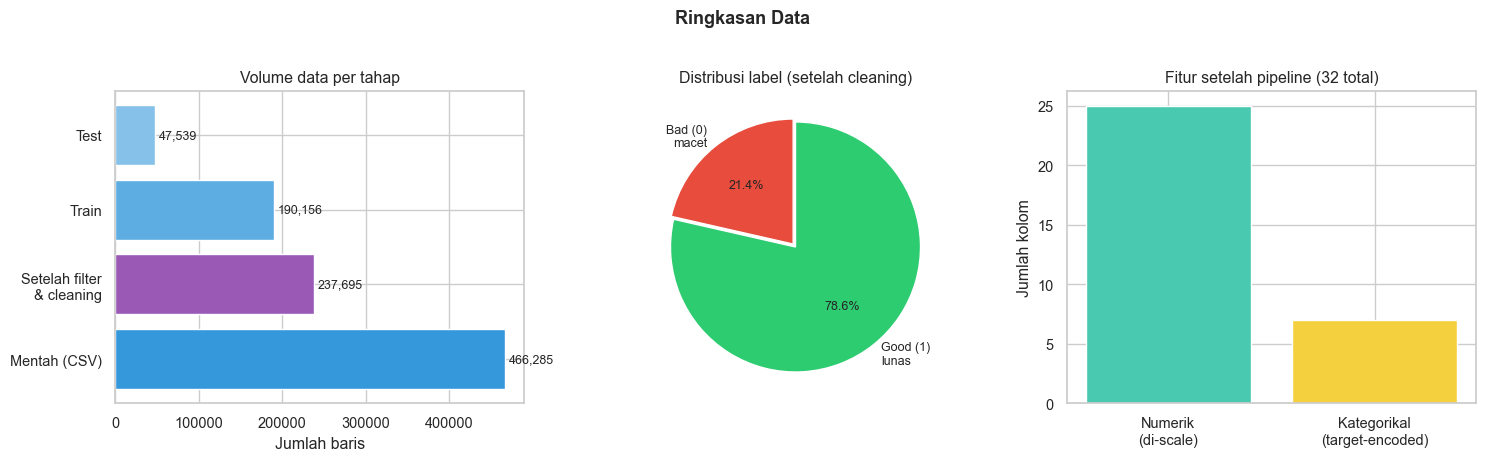

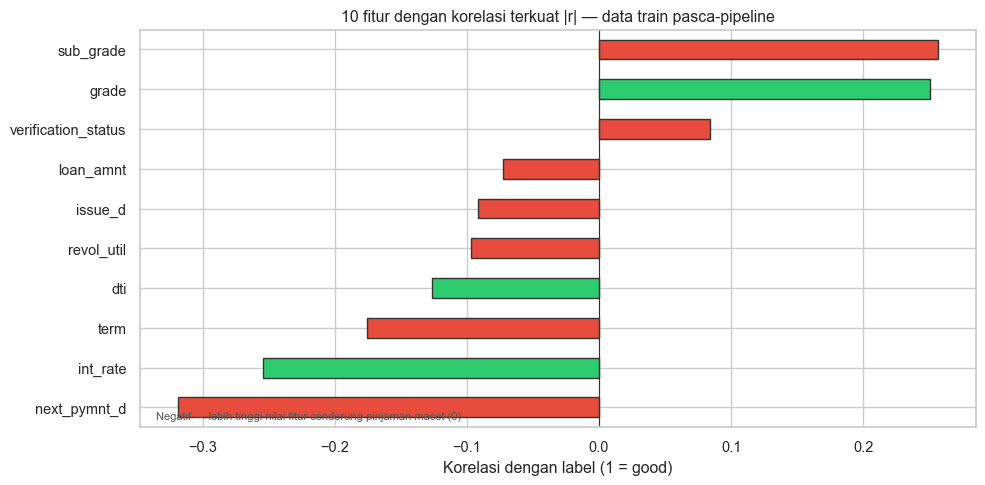

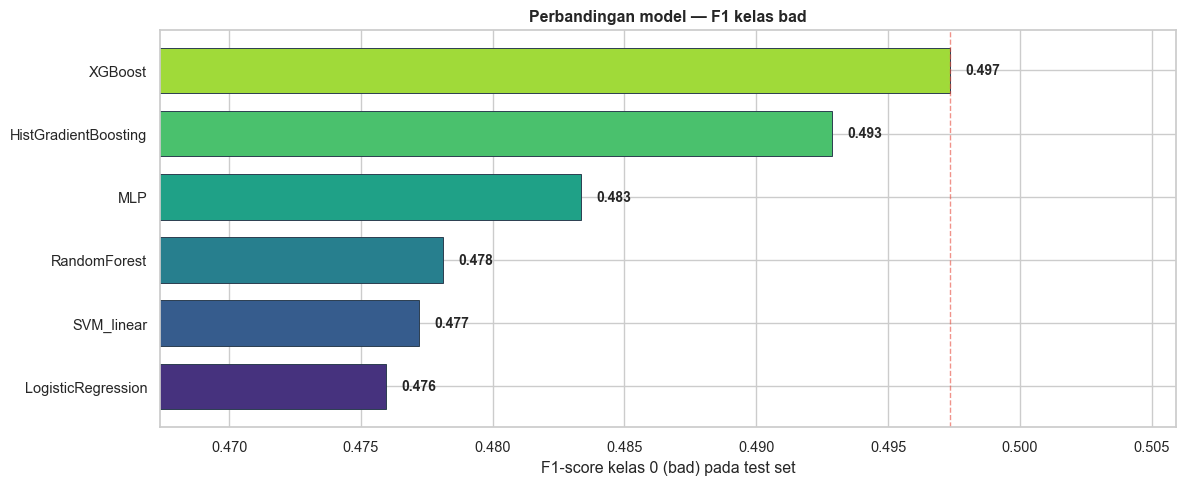

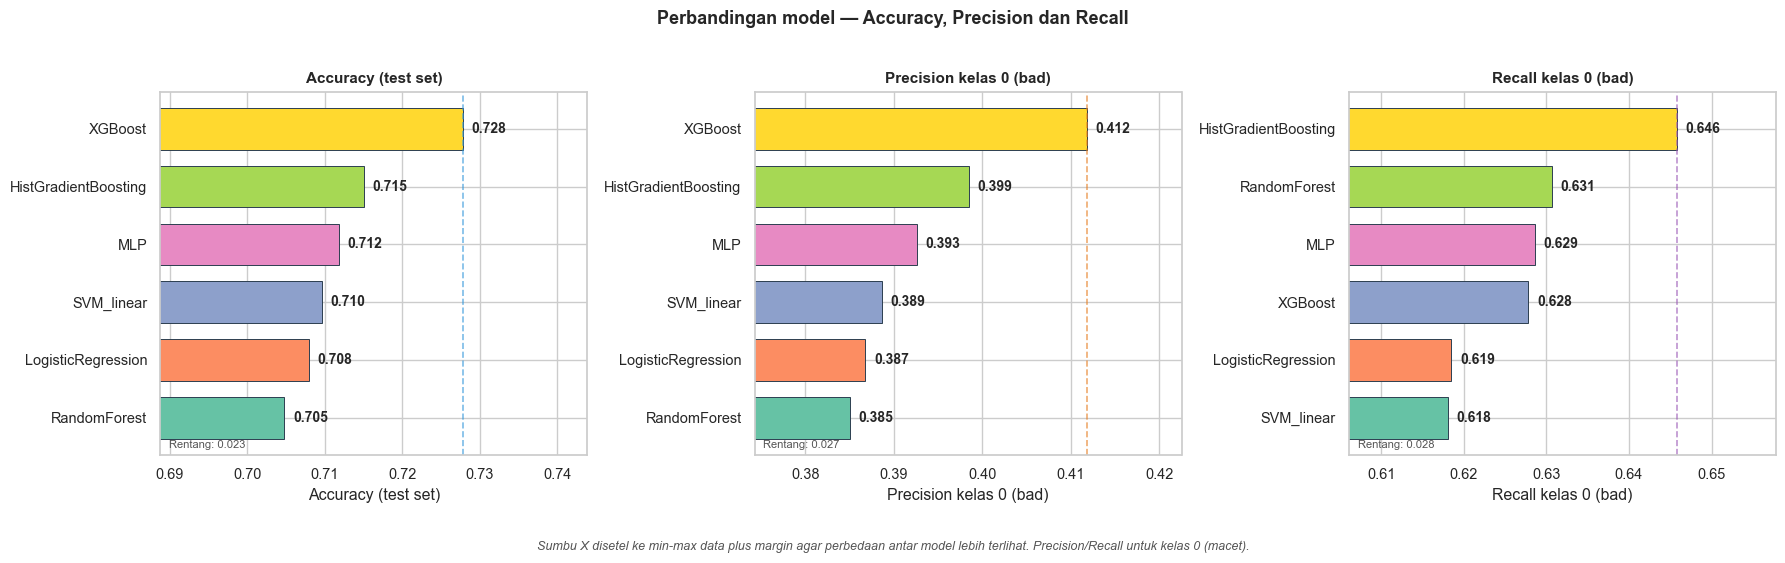

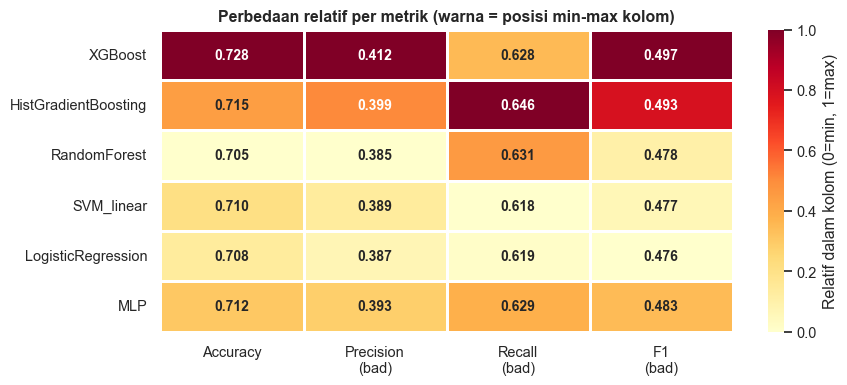

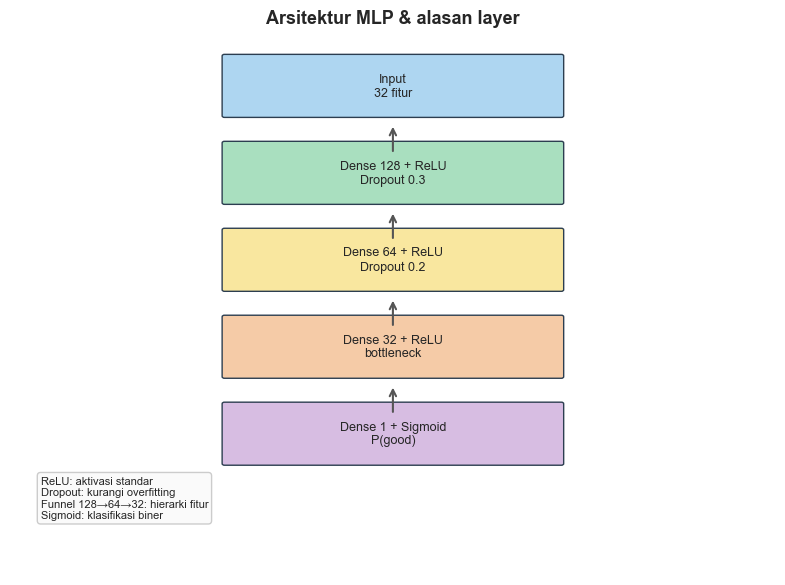

Infografis selesai. Baca sel markdown di atas untuk penjelasan lengkap setiap pilihan desain.


In [42]:
# === Infografis ringkasan proyek (sel baru — tidak mengubah kode asli) ===
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)
SAVE_DIR = Path("saved_models")
PALETTE = {"good": "#2ecc71", "bad": "#e74c3c", "neutral": "#3498db", "accent": "#9b59b6"}

# --- Ambil data dari runtime notebook atau file tersimpan ---
n_raw = len(raw_df) if "raw_df" in dir() else 466_285
n_clean = len(cleaned) if "cleaned" in dir() else 237_695
n_train = len(y_train) if "y_train" in dir() else 190_156
n_test = len(y_test) if "y_test" in dir() else 47_539
n_features = X_train_processed.shape[1] if "X_train_processed" in dir() else 32

if "grid_summary_df" in dir():
    grid_df = grid_summary_df.copy()
elif (SAVE_DIR / "grid_search_summary.csv").exists():
    grid_df = pd.read_csv(SAVE_DIR / "grid_search_summary.csv")
else:
    grid_df = None

if "mlp_metrics" in dir():
    mlp_row = mlp_metrics
elif (SAVE_DIR / "mlp_test_metrics.joblib").exists():
    mlp_row = joblib.load(SAVE_DIR / "mlp_test_metrics.joblib")
else:
    mlp_row = None

if "label_corr" in dir():
    top_corr = label_corr.head(10)
elif "processed_df" in dir():
    top_corr = processed_df.corr()["label"].drop("label").sort_values(
        key=lambda s: s.abs(), ascending=False
    ).head(10)
else:
    top_corr = None

y_all = cleaned["label"] if "cleaned" in dir() else None

# ========== GAMBAR 1: Diagram alur end-to-end ==========
fig1, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")
ax.set_title("Alur Solusi End-to-End — Prediksi Kredit Macet", fontsize=14, fontweight="bold", pad=12)

steps = [
    (0.3, 2.2, "1. Data mentah\nloan_data_2007_2014.csv\n~466k baris"),
    (2.5, 2.2, "2. CustomTransformer\nBersih + fitur + label\n~238k baris"),
    (4.7, 2.2, "3. Split 80/20\nStratified"),
    (6.9, 2.2, "4. Preprocessor\nImpute → TargetEnc → Scale\n32 fitur"),
    (9.1, 2.2, "5. Grid Search\n5 model sklearn"),
    (11.3, 2.2, "6. MLP\nTensorFlow"),
]
colors = ["#aed6f1", "#a9dfbf", "#f9e79f", "#f5cba7", "#d7bde2", "#d2b4de"]

for (x, y, text), color in zip(steps, colors):
    box = FancyBboxPatch(
        (x, y), 1.9, 1.6,
        boxstyle="round,pad=0.05,rounding_size=0.08",
        facecolor=color, edgecolor="#2c3e50", linewidth=1.2,
    )
    ax.add_patch(box)
    ax.text(x + 0.95, y + 0.8, text, ha="center", va="center", fontsize=8, linespacing=1.25)

for i in range(len(steps) - 1):
    x1 = steps[i][0] + 1.9
    x2 = steps[i + 1][0]
    ax.annotate("", xy=(x2, 3.0), xytext=(x1, 3.0),
                arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=2))

ax.text(7, 0.5, "Output: saved_models/ (preprocessor, pipeline, grid search, MLP)",
        ha="center", fontsize=9, style="italic", color="#555")

plt.tight_layout()
plt.show()

# ========== GAMBAR 2: Panel ringkasan data & label ==========
fig2, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Funnel baris
stages = ["Mentah (CSV)", "Setelah filter\n& cleaning", "Train", "Test"]
counts = [n_raw, n_clean, n_train, n_test]
bars = axes[0].barh(stages, counts, color=[PALETTE["neutral"], PALETTE["accent"], "#5dade2", "#85c1e9"])
axes[0].set_title("Volume data per tahap")
axes[0].set_xlabel("Jumlah baris")
for b, c in zip(bars, counts):
    axes[0].text(b.get_width() + max(counts) * 0.01, b.get_y() + b.get_height() / 2,
                 f"{c:,}", va="center", fontsize=9)

# Distribusi label
if y_all is not None:
    vc = y_all.value_counts().sort_index()
    labels_pie = ["Bad (0)\nmacet", "Good (1)\nlunas"]
    axes[1].pie(
        vc.values, labels=labels_pie, autopct="%1.1f%%",
        colors=[PALETTE["bad"], PALETTE["good"]], startangle=90,
        explode=(0.03, 0), textprops={"fontsize": 9},
    )
    axes[1].set_title("Distribusi label (setelah cleaning)")
else:
    axes[1].text(0.5, 0.5, "Jalankan sel cleaning\ndulu", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Distribusi label")

# Komposisi fitur
n_num = len(NUM_FEATURES) if "NUM_FEATURES" in dir() else 25
n_cat = len(CAT_FEATURES) if "CAT_FEATURES" in dir() else 7
axes[2].bar(
    ["Numerik\n(di-scale)", "Kategorikal\n(target-encoded)"],
    [n_num, n_cat],
    color=["#48c9b0", "#f4d03f"],
)
axes[2].set_title(f"Fitur setelah pipeline ({n_features} total)")
axes[2].set_ylabel("Jumlah kolom")

plt.suptitle("Ringkasan Data", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ========== GAMBAR 3: Korelasi top vs label (pasca-pipeline) ==========
if top_corr is not None:
    fig3, ax = plt.subplots(figsize=(10, 5))
    colors_bar = [PALETTE["bad"] if v < 0 else PALETTE["good"] for v in top_corr.values]
    top_corr.sort_values().plot(kind="barh", ax=ax, color=colors_bar, edgecolor="#333")
    ax.axvline(0, color="#333", lw=0.8)
    ax.set_xlabel("Korelasi dengan label (1 = good)")
    ax.set_title("10 fitur dengan korelasi terkuat |r| — data train pasca-pipeline")
    ax.text(0.02, 0.02, "Negatif → lebih tinggi nilai fitur cenderung pinjaman macet (0)",
            transform=ax.transAxes, fontsize=8, color="#555")
    plt.tight_layout()
    plt.show()

# ========== GAMBAR 4–4c: Perbandingan model (accuracy, precision, recall, F1) ==========
# --- Kumpulkan semua metrik test untuk infografis model ---
metrics_rows = []
if grid_df is not None:
    for _, row in grid_df.iterrows():
        metrics_rows.append({
            "model": row["model"],
            "accuracy": row["test_accuracy"],
            "precision_bad": row["test_precision_bad"],
            "recall_bad": row["test_recall_bad"],
            "f1_bad": row["test_f1_bad"],
            "sumber": "GridSearch (test)",
        })
if mlp_row is not None:
    metrics_rows.append({
        "model": "MLP",
        "accuracy": mlp_row["accuracy"],
        "precision_bad": mlp_row["precision_bad"],
        "recall_bad": mlp_row["recall_bad"],
        "f1_bad": mlp_row["f1_bad"],
        "sumber": "MLP (test)",
    })

if metrics_rows:
    metrics_df = pd.DataFrame(metrics_rows)

    def _zoom_xlim(values, pad_ratio=0.4, min_span=0.012):
        """Persempit sumbu X agar batang memenuhi plot dan perbedaan model terlihat."""
        vmin, vmax = float(np.min(values)), float(np.max(values))
        span = max(vmax - vmin, min_span)
        pad = span * pad_ratio
        left = max(0.0, vmin - pad)
        right = min(1.0, vmax + pad)
        return left, right

    n_models = len(metrics_df)
    bar_h = 0.72
    fig_h = max(5, 0.75 * n_models)

    # ========== GAMBAR 4: F1 kelas bad ==========
    cmp_df = metrics_df.sort_values("f1_bad", ascending=True)
    x0, x1 = _zoom_xlim(cmp_df["f1_bad"].values, min_span=0.02)
    fig4, ax = plt.subplots(figsize=(12, fig_h))
    bars = ax.barh(
        cmp_df["model"],
        cmp_df["f1_bad"],
        height=bar_h,
        color=sns.color_palette("viridis", n_colors=n_models),
        edgecolor="#2c3e50",
        linewidth=0.7,
    )
    ax.set_xlim(x0, x1)
    ax.set_xlabel("F1-score kelas 0 (bad) pada test set")
    ax.set_ylabel("")
    ax.set_title("Perbandingan model — F1 kelas bad", fontweight="bold")
    ax.axvline(cmp_df["f1_bad"].max(), color="#e74c3c", ls="--", lw=1, alpha=0.6)
    label_pad = (x1 - x0) * 0.015
    for bar, val in zip(bars, cmp_df["f1_bad"]):
        ax.text(
            val + label_pad,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center",
            fontsize=10,
            fontweight="bold",
        )
    plt.tight_layout()
    plt.show()

    # ========== GAMBAR 4b: Accuracy, Precision, Recall (kelas bad) ==========
    panel_cols = [
        ("accuracy", "Accuracy (test set)", "#3498db", 0.04),
        ("precision_bad", "Precision kelas 0 (bad)", "#e67e22", 0.025),
        ("recall_bad", "Recall kelas 0 (bad)", "#9b59b6", 0.03),
    ]
    fig4b, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    bar_palette = sns.color_palette("Set2", n_colors=n_models)

    for ax, (col, title, color_accent, min_span) in zip(axes, panel_cols):
        plot_df = metrics_df.sort_values(col, ascending=True)
        x0, x1 = _zoom_xlim(plot_df[col].values, min_span=min_span)
        bars = ax.barh(
            plot_df["model"],
            plot_df[col],
            height=bar_h,
            color=bar_palette,
            edgecolor="#2c3e50",
            linewidth=0.7,
        )
        ax.set_xlim(x0, x1)
        ax.set_xlabel(title)
        ax.set_title(title, fontweight="bold", fontsize=11)
        ax.axvline(plot_df[col].max(), color=color_accent, ls="--", lw=1.2, alpha=0.65)
        label_pad = (x1 - x0) * 0.02
        for bar, val in zip(bars, plot_df[col]):
            ax.text(
                val + label_pad,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}",
                va="center",
                fontsize=10,
                fontweight="bold",
            )
        delta = plot_df[col].max() - plot_df[col].min()
        ax.text(
            0.02, 0.02, f"Rentang: {delta:.3f}",
            transform=ax.transAxes, fontsize=8, color="#555",
        )

    fig4b.suptitle(
        "Perbandingan model — Accuracy, Precision dan Recall",
        fontsize=13, fontweight="bold", y=1.02,
    )
    fig4b.text(
        0.5, -0.06,
        "Sumbu X disetel ke min-max data plus margin agar perbedaan antar model lebih terlihat. "
        "Precision/Recall untuk kelas 0 (macet).",
        ha="center", fontsize=9, style="italic", color="#555",
        transform=fig4b.transFigure,
    )
    plt.tight_layout()
    plt.show()

    # ========== GAMBAR 4c: Heatmap metrik (skala per kolom) ==========
    heat_cols = ["accuracy", "precision_bad", "recall_bad", "f1_bad"]
    heat_labels = ["Accuracy", "Precision\n(bad)", "Recall\n(bad)", "F1\n(bad)"]
    heat_data = metrics_df.set_index("model")[heat_cols].copy()
    heat_data.columns = heat_labels
    heat_norm = heat_data.copy()
    for c in heat_norm.columns:
        col = heat_norm[c]
        span = col.max() - col.min()
        heat_norm[c] = (col - col.min()) / (span if span > 0 else 1.0)

    fig4c, ax = plt.subplots(figsize=(9, max(4, 0.55 * n_models)))
    sns.heatmap(
        heat_norm,
        annot=heat_data,
        fmt=".3f",
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        linewidths=0.8,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": "Relatif dalam kolom (0=min, 1=max)"},
        annot_kws={"fontsize": 10, "fontweight": "bold"},
    )
    ax.set_title(
        "Perbedaan relatif per metrik (warna = posisi min-max kolom)",
        fontweight="bold",
    )
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Infografis model: jalankan grid search / MLP atau pastikan saved_models/ ada.")

# ========== GAMBAR 5: Arsitektur MLP (infografis) ==========
fig5, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Arsitektur MLP & alasan layer", fontsize=13, fontweight="bold")

layers = [
    (5, 9.0, f"Input\n{n_features} fitur", "#aed6f1"),
    (5, 7.4, "Dense 128 + ReLU\nDropout 0.3", "#a9dfbf"),
    (5, 5.8, "Dense 64 + ReLU\nDropout 0.2", "#f9e79f"),
    (5, 4.2, "Dense 32 + ReLU\nbottleneck", "#f5cba7"),
    (5, 2.6, "Dense 1 + Sigmoid\nP(good)", "#d7bde2"),
]
for x, y, label, color in layers:
    ax.add_patch(FancyBboxPatch(
        (x - 2.2, y - 0.55), 4.4, 1.1,
        boxstyle="round,pad=0.03", facecolor=color, edgecolor="#2c3e50",
    ))
    ax.text(x, y, label, ha="center", va="center", fontsize=9)
    if y > 2.6:
        ax.annotate("", xy=(5, y - 0.7), xytext=(5, y - 1.25),
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1.5))

reasons = (
    "ReLU: aktivasi standar\n"
    "Dropout: kurangi overfitting\n"
    "Funnel 128→64→32: hierarki fitur\n"
    "Sigmoid: klasifikasi biner"
)
ax.text(0.4, 1.0, reasons, fontsize=8, va="bottom",
        bbox=dict(boxstyle="round", facecolor="#fafafa", edgecolor="#ccc"))

plt.tight_layout()
plt.show()

print("Infografis selesai. Baca sel markdown di atas untuk penjelasan lengkap setiap pilihan desain.")
